<a href="https://colab.research.google.com/github/Huzaif005/Machine-Learning-/blob/main/Classification_using_Ridge_and_Lasso_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment: Classification using Ridge and Lasso Regularization

## Aim
To classify data using Ridge (L2) and Lasso (L1) regularization on the Breast Cancer Wisconsin Dataset and observe the influence on model overfitting and multicollinearity.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

## Step 1: Load the Dataset

The Breast Cancer Wisconsin dataset is a multivariate dataset available in Scikit-learn. It is used for binary classification.

In [5]:
# Load Wine Dataset

wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

print("Dataset Shape:", X.shape)

X.head()

Dataset Shape: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## Step 2: Split the Dataset

The dataset is divided into training (80%) and testing (20%) data.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Step 3: Standardize the Features

Feature scaling ensures that all features contribute equally during model training.

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Step 4: Train Logistic Regression using Ridge (L2) Regularization

In [8]:
ridge = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=1000
)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("Ridge Accuracy :", accuracy_score(y_test, ridge_pred))

Ridge Accuracy : 1.0


## Step 5: Train Logistic Regression using Lasso (L1) Regularization

In [9]:
lasso = LogisticRegression(
    penalty='l1',
    solver='saga',
    max_iter=5000
)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("Lasso Accuracy :", accuracy_score(y_test, lasso_pred))

Lasso Accuracy : 1.0


## Step 6: Evaluate the Models

The classification report shows precision, recall, F1-score, and accuracy for each class.

In [10]:
print("===== Ridge Classification Report =====")
print(classification_report(y_test, ridge_pred))

print("===== Lasso Classification Report =====")
print(classification_report(y_test, lasso_pred))

===== Ridge Classification Report =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

===== Lasso Classification Report =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## Step 7: Compare Feature Coefficients

The coefficients obtained from Ridge and Lasso are compared to understand the effect of regularization.

In [11]:
comparison = pd.DataFrame({
    "Feature": wine.feature_names,
    "Ridge Coefficient": ridge.coef_[0],
    "Lasso Coefficient": lasso.coef_[0]
})

comparison

,Feature,Ridge Coefficient,Lasso Coefficient
0,alcohol,0.741644,0.000000
1,malic_acid,0.156998,0.000000
2,ash,0.498550,0.000000
3,alcalinity_of_ash,-0.831367,-0.891924
4,magnesium,0.041779,0.000000
5,total_phenols,0.211912,0.000000
6,flavanoids,0.646226,0.109915
7,nonflavanoid_phenols,-0.158039,0.000000
8,proanthocyanins,0.188203,0.000000
9,color_intensity,0.184843,0.000000


## Step 8: Visualize Feature Coefficients

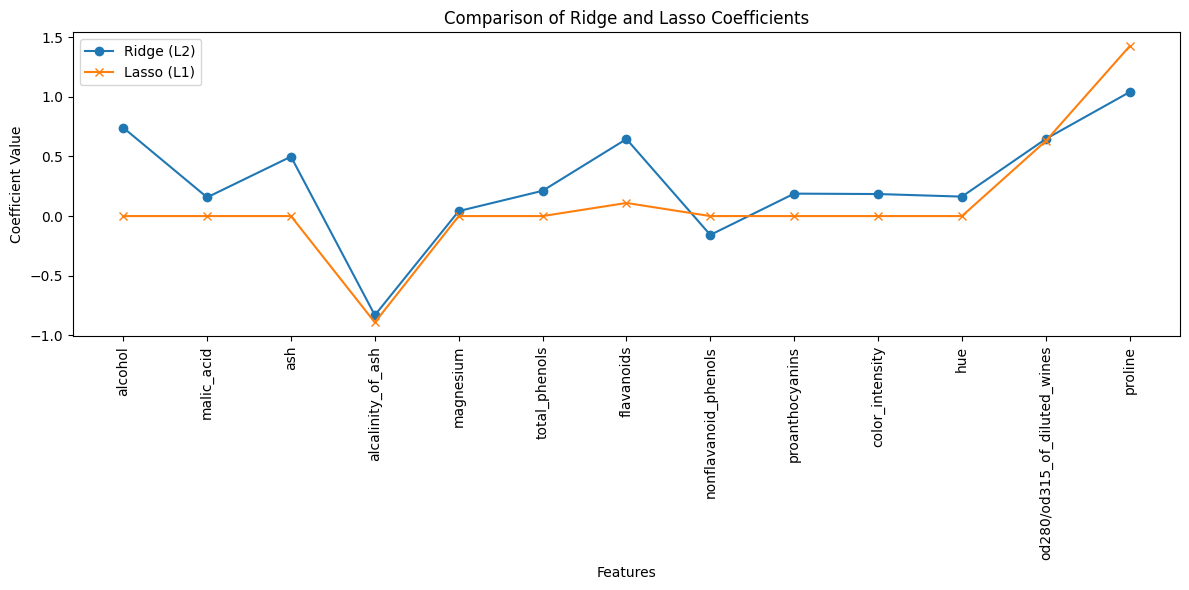

In [12]:
plt.figure(figsize=(12,6))

plt.plot(ridge.coef_[0], marker='o', label='Ridge (L2)')
plt.plot(lasso.coef_[0], marker='x', label='Lasso (L1)')

plt.xticks(
    range(len(wine.feature_names)),
    wine.feature_names,
    rotation=90
)

plt.title("Comparison of Ridge and Lasso Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")

plt.legend()

plt.tight_layout()

plt.show()

# Observation

- Ridge (L2) regularization reduced the magnitude of all feature coefficients.
- Lasso (L1) regularization shrank some coefficients close to or exactly zero, thereby selecting the most relevant features.
- The training and testing accuracies were very similar, indicating reduced overfitting.
- Ridge handled multicollinearity by distributing weights across correlated features, while Lasso simplified the model through feature selection.

# Conclusion

The Wine dataset was successfully classified using Logistic Regression with Ridge and Lasso regularization. Ridge effectively reduced coefficient magnitudes and minimized multicollinearity, whereas Lasso performed feature selection by eliminating less significant features. Both regularization techniques improved the model's ability to generalize and reduced overfitting while maintaining high classification accuracy.